<a href="https://colab.research.google.com/github/VENKATCHINTHAKINDI01/Flipkart-Analysis/blob/main/ZOMZTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [90]:
name_metadata_df = pd.read_csv('/content/Restaurant names and Metadata.csv')
reviews_df = pd.read_csv('/content/Restaurant reviews.csv')

In [91]:
restaurants = name_metadata_df.copy()
reviews = reviews_df.copy()

In [92]:
restaurants.shape

(105, 6)

In [93]:
restaurants.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [94]:
restaurants['Cost'] = restaurants['Cost'].str.replace(",","").astype('int64')

In [95]:
restaurants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    int64 
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.0+ KB


In [96]:
restaurants.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [97]:
reviews.shape

(10000, 7)

In [98]:
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [99]:
reviews.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [100]:
reviews.dropna(inplace = True)

In [101]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9955 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  9955 non-null   object
 1   Reviewer    9955 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9955 non-null   object
 4   Metadata    9955 non-null   object
 5   Time        9955 non-null   object
 6   Pictures    9955 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 622.2+ KB


In [102]:
reviews['Rating'].value_counts()

,count
Rating,
5,3826
4,2373
1,1735
3,1192
2,684
4.5,69
3.5,47
2.5,19
1.5,9


 'like' which is inconvertible to a number so the only way I can convert this functionality to type 'float64' is to omit that data

In [103]:
reviews=reviews[reviews['Rating']!='Like']

In [104]:
# Convert 'Rating' column to float
reviews['Rating'] = reviews['Rating'].astype('float64')

# Split 'Metadata' into 'Reviews' and 'Followers' and expand into separate columns
reviews[['Reviews', 'Followers']] = reviews['Metadata'].str.split(',', expand=True)

# Convert 'Reviews' and 'Followers' to numeric after extracting the relevant numeric parts
reviews['Reviews'] = pd.to_numeric(reviews['Reviews'].str.split(' ').str[0], errors='coerce')
reviews['Followers'] = pd.to_numeric(reviews['Followers'].str.split(' ').str[1], errors='coerce')

# Convert 'Time' column to datetime format
reviews['Time'] = pd.to_datetime(reviews['Time'], errors='coerce')

# Extract the year and hour from 'Time'
reviews['Year'] = reviews['Time'].dt.year
reviews['Hour'] = reviews['Time'].dt.hour

# Drop the 'Metadata' column as it's no longer needed
reviews = reviews.drop(['Metadata'], axis=1)

# Display the data types of the modified DataFrame
print(reviews.dtypes)


Restaurant            object
Reviewer              object
Review                object
Rating               float64
Time          datetime64[ns]
Pictures               int64
Reviews                int64
Followers            float64
Year                   int32
Hour                   int32
dtype: object


In [105]:
reviews.head()

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Year,Hour
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,2019-05-25 15:54:00,0,1,2.0,2019,15
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,2019-05-25 14:20:00,0,3,2.0,2019,14
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,2019-05-24 22:54:00,0,2,3.0,2019,22
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,2019-05-24 22:11:00,0,1,1.0,2019,22
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,2019-05-24 21:37:00,0,3,2.0,2019,21


In [106]:
# Assuming cuis_list is a dictionary where keys are cuisine names and values are counts
cuis_df = pd.DataFrame(cuis_list.values(), index=cuis_list.keys(), columns=['Counts of Restaurants'])
cuis_df.sort_values(by='Counts of Restaurants', ascending=False, inplace=True) # Sort the DataFrame in descending order
top_10_cuis = cuis_df.head(10) # Select the top 10 cuisines

# Display the top 10 cuisines DataFrame
print(top_10_cuis)


              Counts of Restaurants
North Indian                     61
Chinese                          43
Continental                      21
Biryani                          16
Fast Food                        15
Asian                            15
Italian                          14
Desserts                         13
South Indian                      9
Bakery                            7


Text(0.5, 1.0, 'Most popular cuisines at Restaurants in Hyderabad')

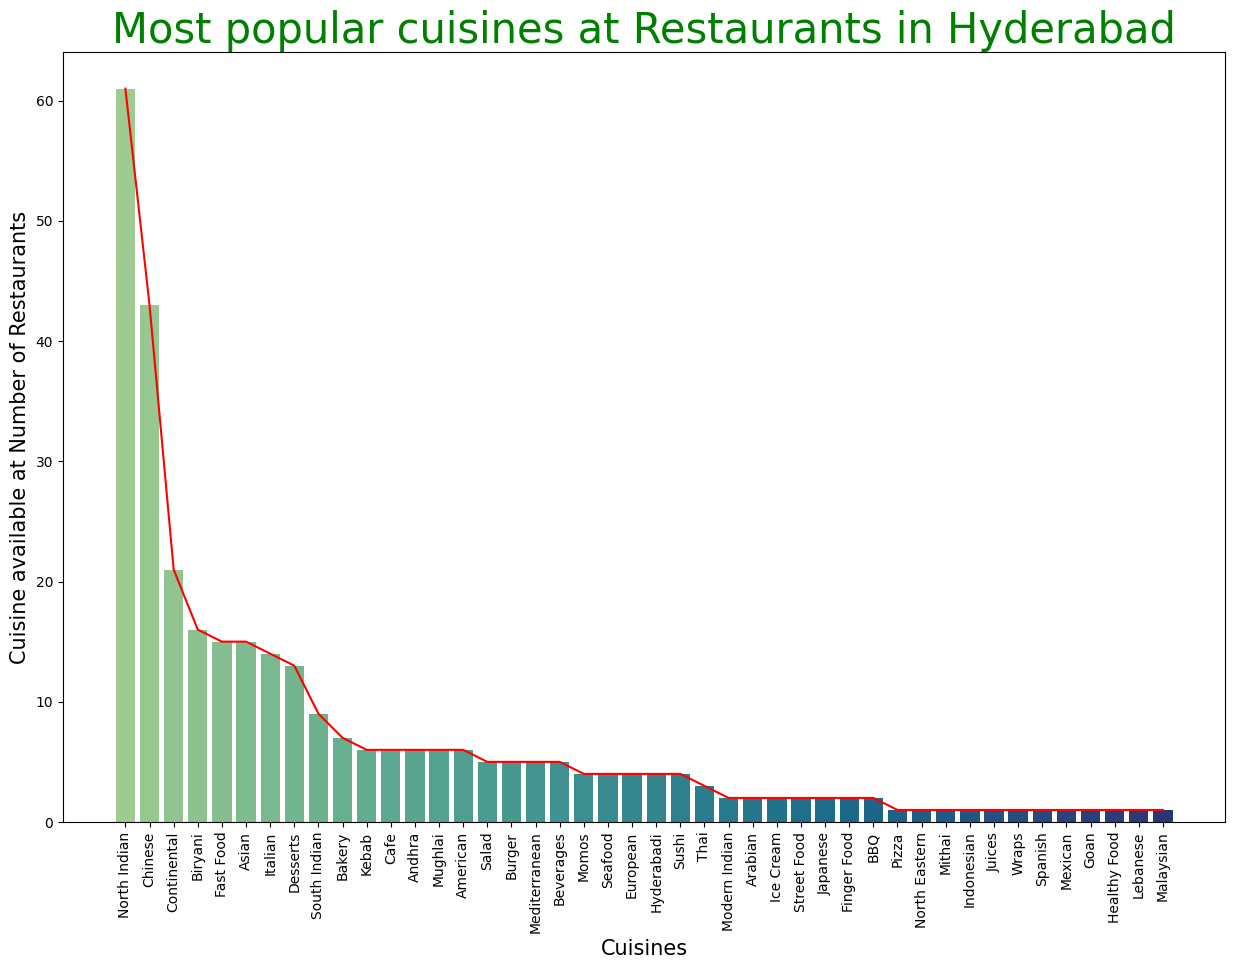

In [107]:
plt.figure(figsize=(15,10))
plt.plot(cuis_df.index,cuis_df['Counts of Restaurants'],color='red')
plt.bar(cuis_df.index,cuis_df['Counts of Restaurants'],color= sns.color_palette("crest",len (cuis_df.index)))
plt.xlabel('Cuisines',size=15)
plt.xticks(rotation=90)
plt.ylabel('Cuisine available at Number of Restaurants',size=15)
plt.title('Most popular cuisines at Restaurants in Hyderabad',size=30, color = 'green')


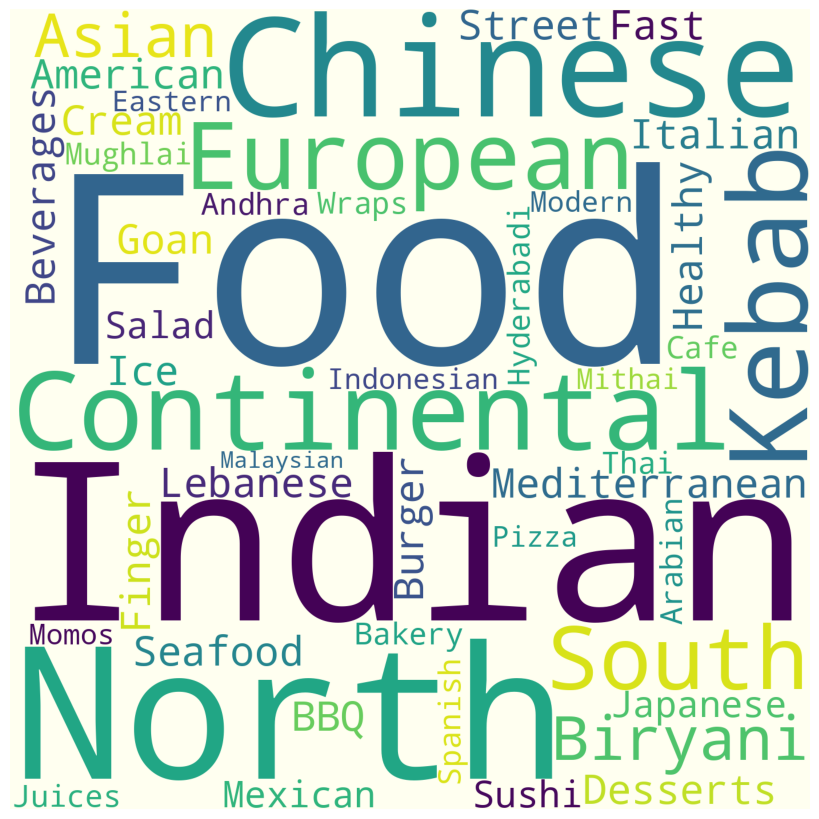

In [108]:
from wordcloud import WordCloud, STOPWORDS
words_list = cuis_list.keys()
strr = ' '
for i in words_list:
    strr=strr+i+' '

wordcloud = WordCloud(width = 1400, height = 1400,
                background_color ='ivory',
                min_font_size = 12).generate(strr)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

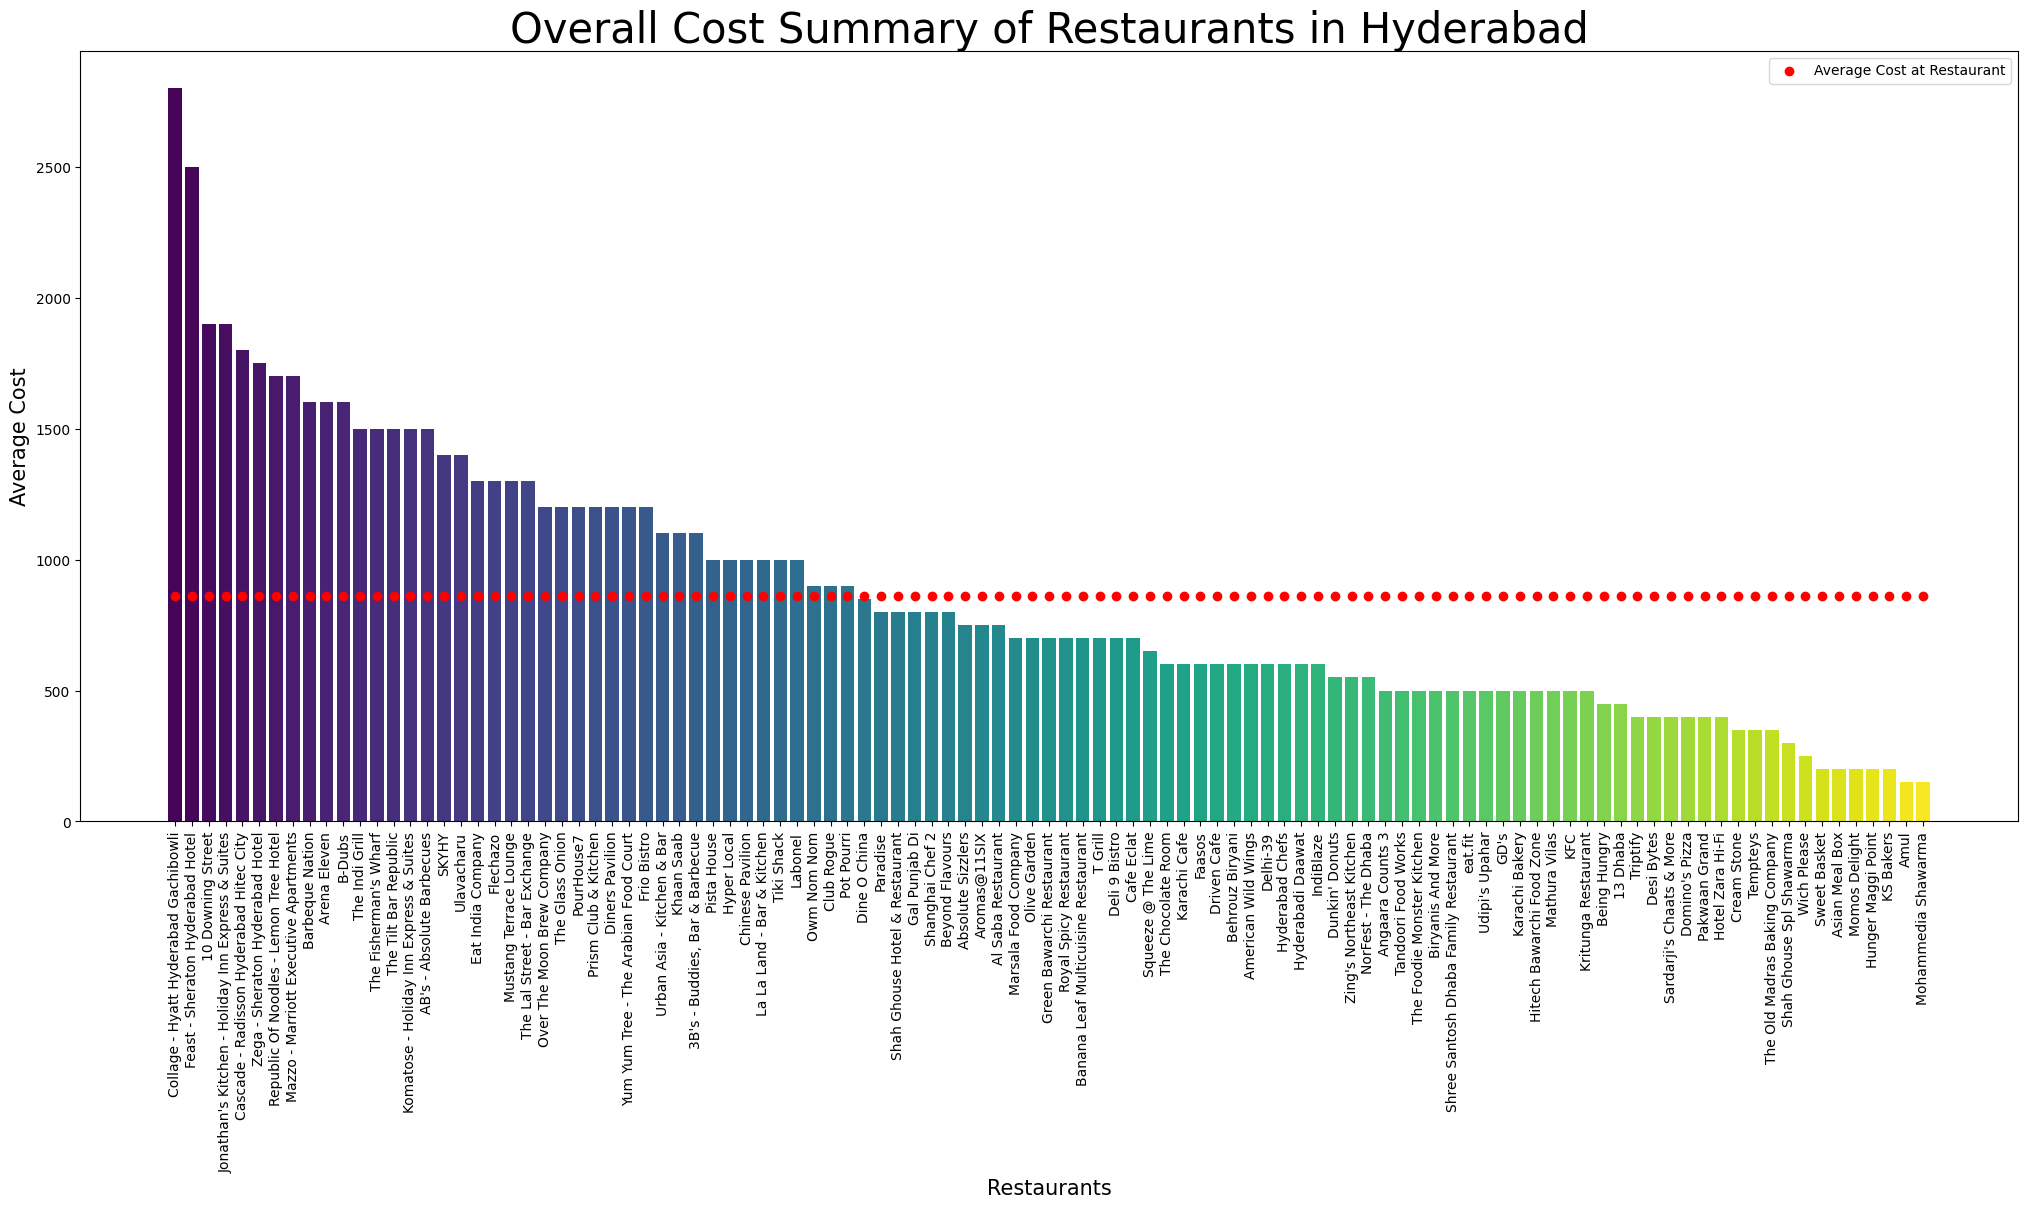

In [109]:
restaurants_cost=restaurants.groupby('Name').apply(lambda x:np.average(x['Cost'])).reset_index(name='Cost')
restaurants_cost.sort_values(by='Cost',ascending=False,inplace=True)
avg=np.average(restaurants_cost['Cost'])
plt.figure(figsize=(25,10))
plt.bar(restaurants_cost['Name'],restaurants_cost['Cost'], color = sns.color_palette("viridis", len(restaurants_cost['Name'])))
for i in restaurants_cost['Name']:
    plt.scatter(i,avg,color='red')
plt.xlabel('Restaurants',size=15)
plt.xticks(rotation=90)
plt.ylabel('Average Cost',size=15)
plt.title('Overall Cost Summary of Restaurants in Hyderabad',size=30)
plt.legend(['Average Cost at Restaurant'])

Text(0, 0.5, 'Average Cost')

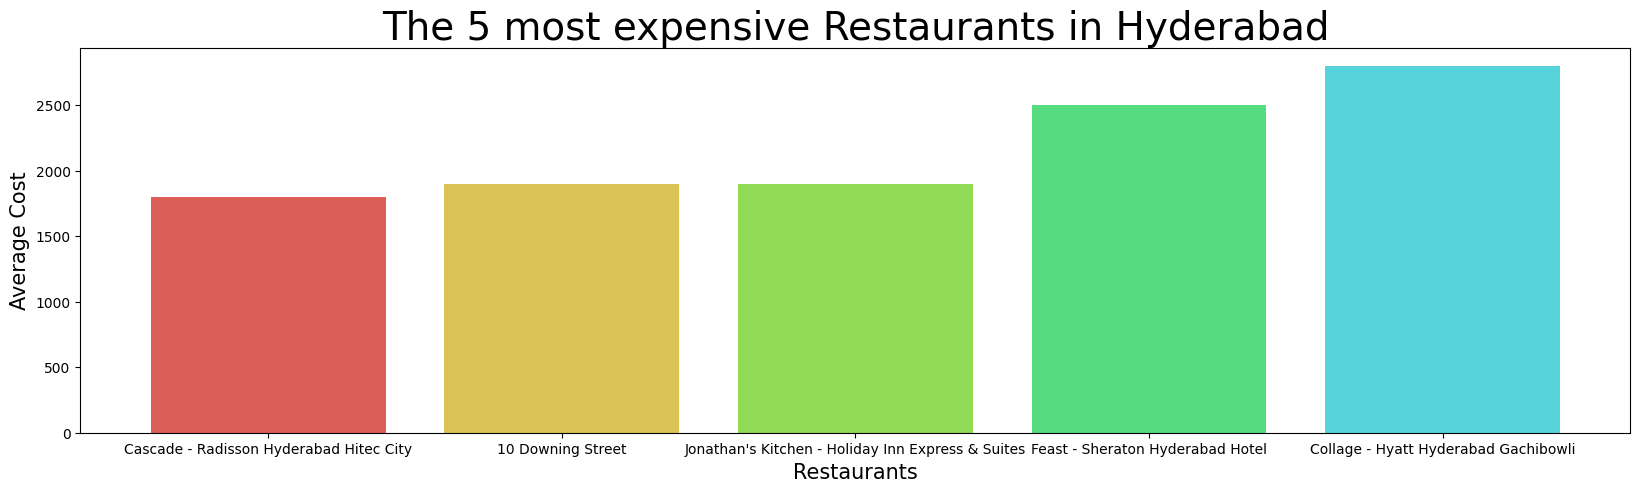

In [110]:
best_5_rest = restaurants_cost[:5]
best_5_rest.sort_values(by='Cost',ascending=True,inplace=True)
plt.figure(figsize=(20,5))
plt.bar(best_5_rest['Name'],best_5_rest['Cost'], color = sns.color_palette("hls", 8))
plt.title('The 5 most expensive Restaurants in Hyderabad',size=28)
plt.xlabel('Restaurants',size=15)
plt.ylabel('Average Cost',size=15)

Text(0, 0.5, 'Average Cost')

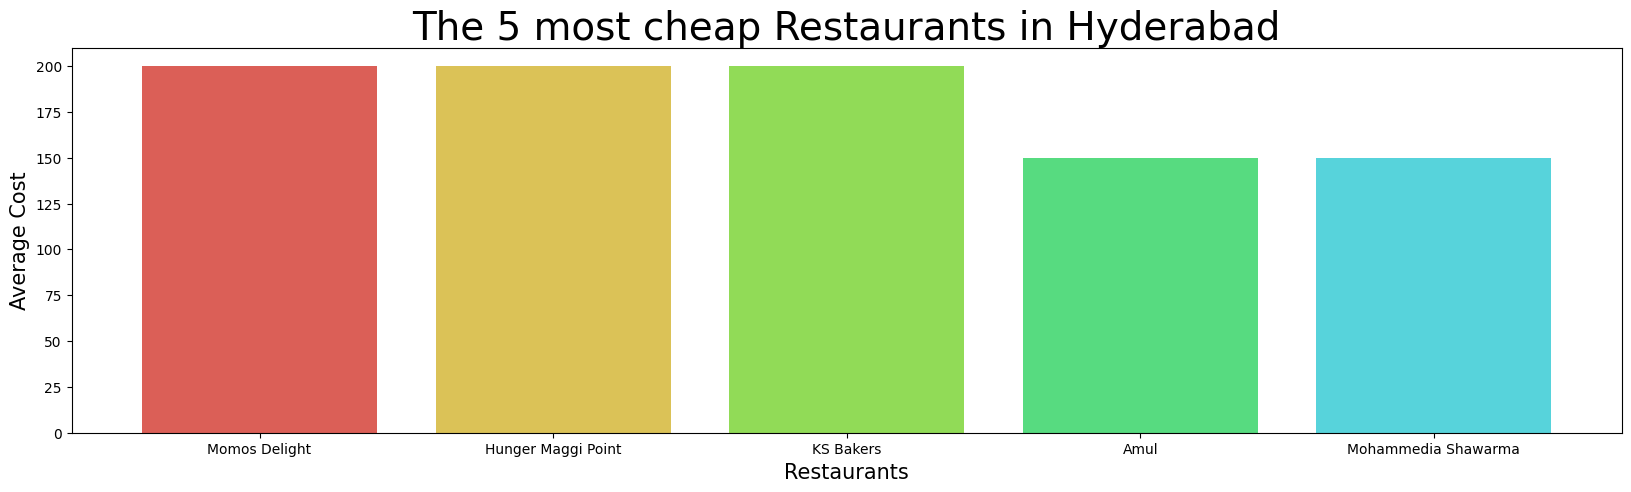

In [111]:
worst_5_rest = restaurants_cost[-5:]
plt.figure(figsize=(20,5))
plt.bar(worst_5_rest['Name'],worst_5_rest['Cost'], color = sns.color_palette("hls", 8))
plt.title('The 5 most cheap Restaurants in Hyderabad',size=28)
plt.xlabel('Restaurants',size=15)
plt.ylabel('Average Cost',size=15)

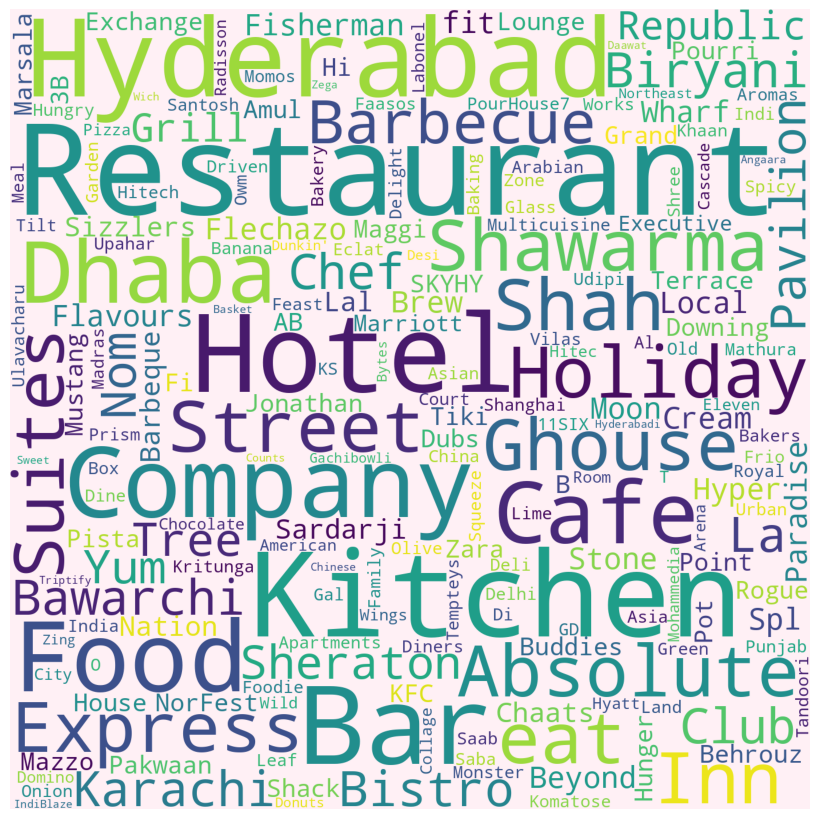

In [112]:
Rests = restaurants.Name.unique()
rest_string = ' '
for i in Rests:
   rest_string = rest_string+i+' '

wordcloud = WordCloud(width = 1400, height = 1400,
                background_color ='lavenderblush',
                min_font_size = 12).generate(rest_string)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

In [113]:
reviewer_list = reviews.groupby('Reviewer').apply(lambda x: x['Reviewer'].count()).reset_index(name='Review Count')
reviewer_list = reviewer_list.sort_values(by = 'Review Count',ascending=False)
top_reviewers = reviewer_list[:15]

Text(0, 0.5, 'N° of reviews')

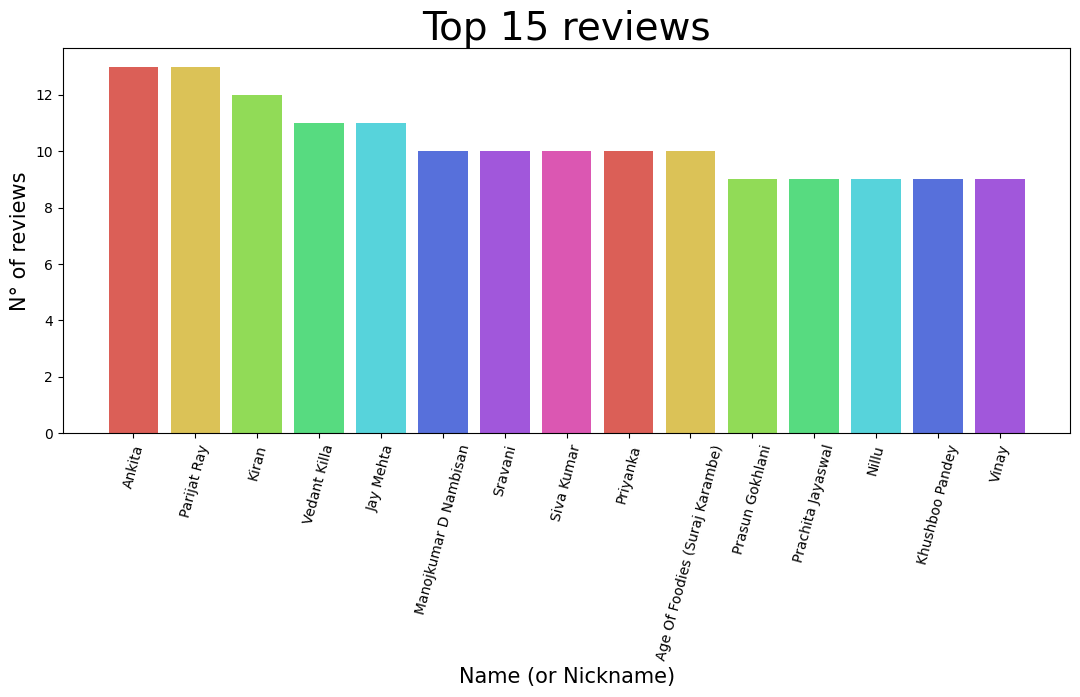

In [114]:
plt.figure(figsize=(13,5))
plt.bar(top_reviewers['Reviewer'], top_reviewers['Review Count'], color = sns.color_palette("hls", 8))
plt.xticks(rotation=75)
plt.title('Top 15 reviews',size=28)
plt.xlabel('Name (or Nickname)',size=15)
plt.ylabel('N° of reviews',size=15)

In [115]:
review_ratings=reviews.groupby('Reviewer').apply(lambda x:np.average(x['Rating'])).reset_index(name='Average Ratings')
review_ratings=pd.merge(top_reviewers,review_ratings,how='inner',left_on='Reviewer',right_on='Reviewer')
top_reviewers_ratings=review_ratings[:15]

In [116]:
top_reviewers_ratings

,Reviewer,Review Count,Average Ratings
0,Ankita,13,3.923077
1,Parijat Ray,13,3.192308
2,Kiran,12,4.500000
3,Vedant Killa,11,4.000000
4,Jay Mehta,11,3.727273
5,Manojkumar D Nambisan,10,3.700000
6,Sravani,10,4.000000
7,Siva Kumar,10,3.600000
8,Priyanka,10,2.600000
9,Age Of Foodies (Suraj Karambe),10,3.500000


Text(0.5, 1.0, 'Average Ratings per Review Submitted Distribution')

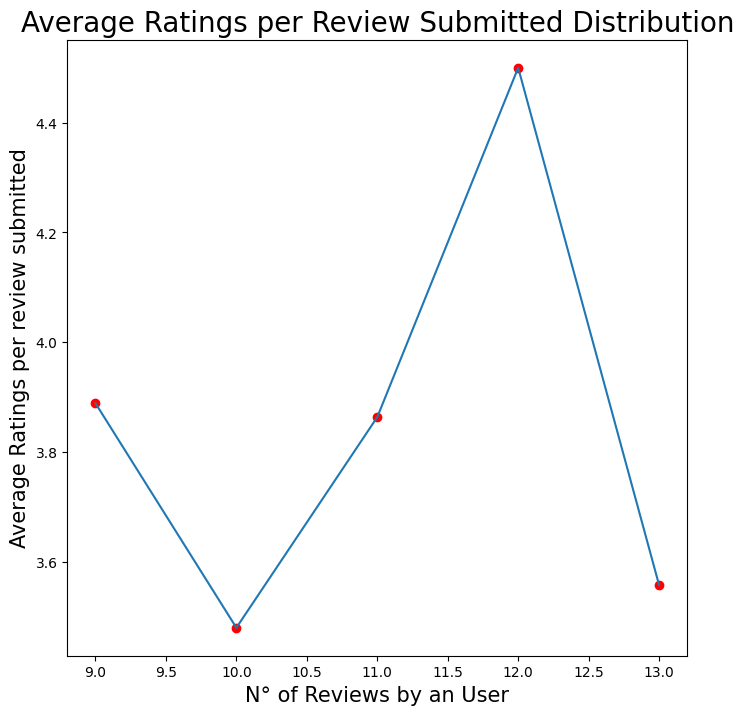

In [117]:
review_ratings_plot = top_reviewers_ratings.groupby('Review Count').apply(lambda x:np.average(x['Average Ratings'])).reset_index(name='Average')
plt.figure(figsize=(8,8))
plt.plot(review_ratings_plot['Review Count'],review_ratings_plot['Average'])
plt.scatter(review_ratings_plot['Review Count'],review_ratings_plot['Average'],color='red')
plt.xlabel('N° of Reviews by an User',size=15)
plt.ylabel('Average Ratings per review submitted',size=15)
plt.title('Average Ratings per Review Submitted Distribution',size=20)

In [118]:
review_follow_1=reviews.groupby('Year').apply(lambda x:np.sum(x['Reviews'])).reset_index(name='Total Reviews')
review_follow_2=reviews.groupby('Year').apply(lambda x:np.max(x['Followers'])).reset_index(name='Total Followers')
pictures =reviews.groupby('Year').apply(lambda x:np.sum(x['Pictures'])).reset_index(name='Total Pictures')
review_follow=pd.merge(review_follow_1,review_follow_2, how='inner',left_on='Year',right_on='Year')
review_follow=pd.merge(review_follow, pictures, how='inner',left_on='Year',right_on='Year')
review_follow


,Year,Total Reviews,Total Followers,Total Pictures
0,2016,4534,3353.0,84
1,2017,12784,5451.0,276
2,2018,107637,13410.0,2827
3,2019,114020,13410.0,4298


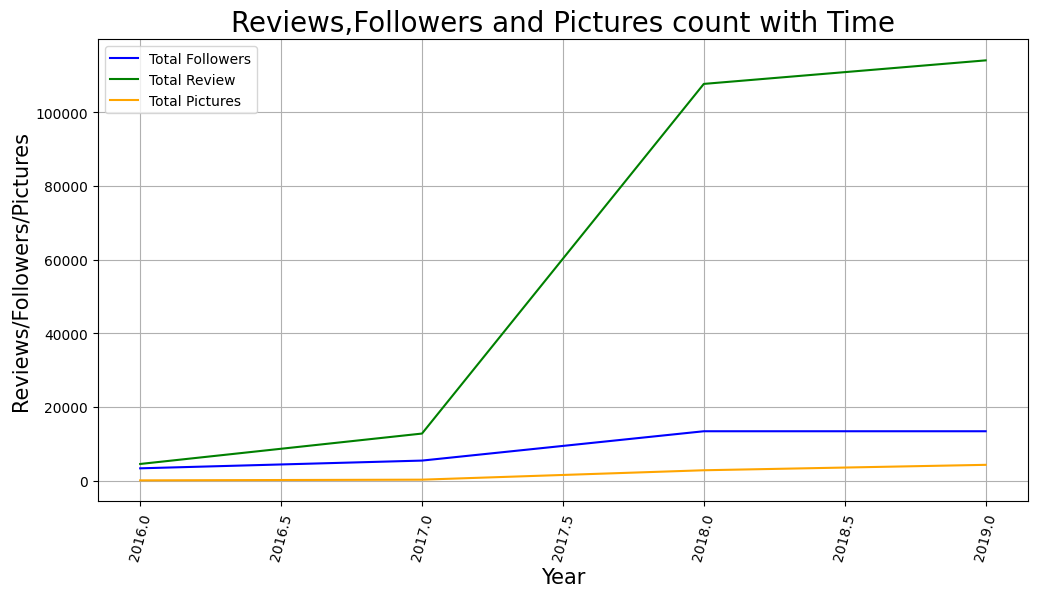

In [119]:
plt.figure(figsize=(12,6))
plt.plot(review_follow['Year'],review_follow['Total Followers'], color = 'blue')
plt.plot(review_follow['Year'],review_follow['Total Reviews'], color = "green")
plt.plot(review_follow['Year'],review_follow['Total Pictures'], color = "orange")
plt.xlabel('Year',size=15)
plt.xticks(rotation=75)
plt.grid()
plt.ylabel('Reviews/Followers/Pictures',size=15)
plt.title('Reviews,Followers and Pictures count with Time',size=20)
plt.legend(['Total Followers','Total Review', 'Total Pictures'])

In [120]:

reviews_for_hour = reviews.groupby('Hour').apply(lambda x: x['Hour'].count()).reset_index(name='Reviews per hour')
reviews_for_hour

,Hour,Reviews per hour
0,0,509
1,1,313
2,2,167
3,3,102
4,4,55
5,5,39
6,6,44
7,7,78
8,8,134
9,9,171


Text(0, 0.5, 'N° of reviews')

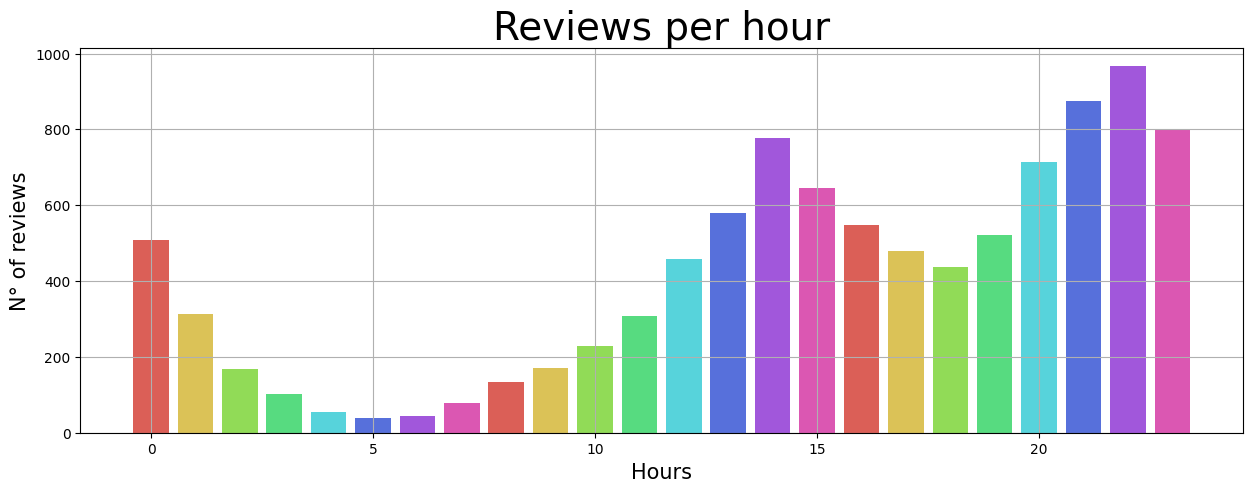

In [121]:
plt.figure(figsize=(15,5))
plt.bar(reviews_for_hour['Hour'], reviews_for_hour['Reviews per hour'], color = sns.color_palette("hls", 8))
plt.title('Reviews per hour',size=28)
plt.grid()
plt.xlabel('Hours',size=15)
plt.ylabel('N° of reviews',size=15)

In [122]:
df_merged= reviews.merge(restaurants, how='inner', left_on='Restaurant', right_on='Name')
df_merged.head(1)

,Restaurant,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Year,Hour,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,2019-05-25 15:54:00,0,1,2.0,2019,15,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


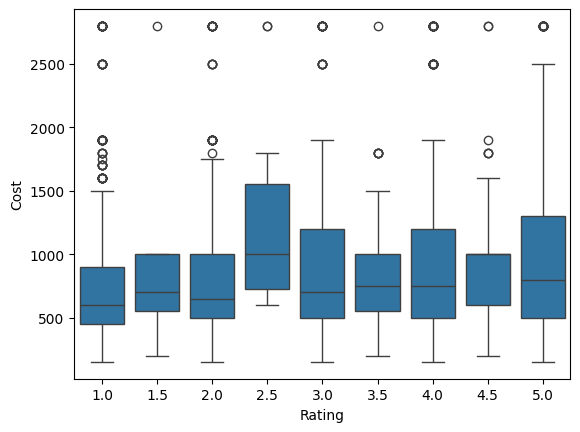

In [123]:

# Create the box plot with Seaborn
sns.boxplot(x='Rating', y='Cost', data=df_merged)

# Display the plot
plt.show()


In [124]:
from warnings import filterwarnings
filterwarnings('ignore')
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import PorterStemmer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [125]:
# Renaming the restaurant name column with the same value as in the other data set:
reviews = reviews.rename(columns={'Restaurant': 'Name'})
reviews.head()

,Name,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Year,Hour
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,2019-05-25 15:54:00,0,1,2.0,2019,15
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,2019-05-25 14:20:00,0,3,2.0,2019,14
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,2019-05-24 22:54:00,0,2,3.0,2019,22
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,2019-05-24 22:11:00,0,1,1.0,2019,22
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,2019-05-24 21:37:00,0,3,2.0,2019,21


In [126]:
df = pd.merge(reviews, restaurants, how='left', on='Name')
df.head(3)

,Name,Reviewer,Review,Rating,Time,Pictures,Reviews,Followers,Year,Hour,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,2019-05-25 15:54:00,0,1,2.0,2019,15,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,2019-05-25 14:20:00,0,3,2.0,2019,14,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,2019-05-24 22:54:00,0,2,3.0,2019,22,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


In [127]:
# Dropping the columns which I am not going to use:
df.drop(['Reviewer', 'Time', 'Pictures', 'Links', 'Collections'], axis=1, inplace=True)
df.head(3)

,Name,Review,Rating,Reviews,Followers,Year,Hour,Cost,Cuisines,Timings
0,Beyond Flavours,"The ambience was good, food was quite good . h...",5.0,1,2.0,2019,15,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...,5.0,3,2.0,2019,14,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...,5.0,2,3.0,2019,22,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


In [128]:
# Convert 'Cost' column to string type, then remove commas and convert to integer
df['Cost'] = df['Cost'].astype(str).str.replace(',', '').astype(int)

# For 'Rating', replace 'Like' with '1' and convert to float
df['Rating'] = df['Rating'].astype(str).str.replace('Like', '1').astype(float)

# Check the data types to ensure the conversions were successful
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9954 entries, 0 to 9953
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       9954 non-null   object 
 1   Review     9954 non-null   object 
 2   Rating     9954 non-null   float64
 3   Reviews    9954 non-null   int64  
 4   Followers  8380 non-null   float64
 5   Year       9954 non-null   int32  
 6   Hour       9954 non-null   int32  
 7   Cost       9954 non-null   int64  
 8   Cuisines   9954 non-null   object 
 9   Timings    9854 non-null   object 
dtypes: float64(2), int32(2), int64(2), object(4)
memory usage: 700.0+ KB


In [129]:
print('No of data inputs:', len(df))
print('no of NaN values for each column:\n')
print(df.isnull().sum())

No of data inputs: 9954
no of NaN values for each column:

Name            0
Review          0
Rating          0
Reviews         0
Followers    1574
Year            0
Hour            0
Cost            0
Cuisines        0
Timings       100
dtype: int64


In [130]:
# Finding missing Rating values:
df['Name'][df['Rating'].isnull() == True].value_counts()

,count
Name,


In [131]:
print('Mean of Rating for American Wild Wings: ', df['Rating'][df['Name'] == 'American Wild Wings'].mean())
print('Mean of Rating for Arena Eleven: ', df['Rating'][df['Name'] == 'Arena Eleven'].mean())
print('Overall Mean of Ratings: ', df['Rating'].mean())

Mean of Rating for American Wild Wings:  3.9740259740259742
Mean of Rating for Arena Eleven:  4.117647058823529
Overall Mean of Ratings:  3.600261201527024


In [132]:
df['Rating'].fillna(4, inplace=True)

# Changing NaN reviews by '-' becouse it will not create any probleme and NAN values can be handeled easily
df['Review'] = df['Review'].fillna('-')
df.isnull().sum()


,0
Name,0
Review,0
Rating,0
Reviews,0
Followers,1574
Year,0
Hour,0
Cost,0
Cuisines,0
Timings,100


In [133]:
# sample examples of these columns before text processing:
df[['Review', 'Cuisines']].head(5)

,Review,Cuisines
0,"The ambience was good, food was quite good . h...","Chinese, Continental, Kebab, European, South I..."
1,Ambience is too good for a pleasant evening. S...,"Chinese, Continental, Kebab, European, South I..."
2,A must try.. great food great ambience. Thnx f...,"Chinese, Continental, Kebab, European, South I..."
3,Soumen das and Arun was a great guy. Only beca...,"Chinese, Continental, Kebab, European, South I..."
4,Food is good.we ordered Kodi drumsticks and ba...,"Chinese, Continental, Kebab, European, South I..."


In [134]:
df.sample(5)

,Name,Review,Rating,Reviews,Followers,Year,Hour,Cost,Cuisines,Timings
2756,"3B's - Buddies, Bar & Barbecue",Very nice food and awesome service by Govind. ...,5.0,1,3.0,2019,14,1100,"North Indian, Mediterranean, European","12 Noon to 4 PM, 6:30 PM to 11:30 PM"
7017,Urban Asia - Kitchen & Bar,"Food is very nice, especially chilli lamb and ...",5.0,12,4.0,2019,22,1100,"Asian, Thai, Chinese, Sushi, Momos","12 Noon to 3 PM, 7 PM to 11 PM"
950,Cream Stone,Ordered Nuts Overloaded. Tasted like nothing y...,5.0,7,70.0,2019,2,350,"Ice Cream, Desserts","10 AM to 1 AM (Mon-Thu), 10 AM to 1:30 AM (Fri..."
6165,Prism Club & Kitchen,"India’s best club to do party on weekends, pow...",5.0,10,67.0,2019,2,1200,"Kebab, Continental, Italian, North Indian",5pm to 12midnight (Mon-Sun)
7398,Faasos,What did I order?\n\nI ordered Reshmi Chicken ...,5.0,148,1995.0,2019,14,600,"Fast Food, Biryani, Desserts",9 AM to 1 AM


In [135]:
replace_space = re.compile('[/(){}\[\]\|@,;]')
# Define symbols to be removed
remove_symbols = re.compile('[^0-9a-z #+_]')
# Define stopwords
stopwords = set(stopwords.words('english'))


def text_preprocessing(text):
    # Lowercase all the letters
    text = text.lower()

    # Replace these symbols with space
    text = replace_space.sub(' ', text)

    # Remove these symbols
    text = remove_symbols.sub('', text)

    # Remove stopwords
    text = ' '.join(word for word in text.split() if word not in stopwords)

    return text


In [136]:
df['Review'] = df['Review'].apply(text_preprocessing)
df['Cuisines'] = df['Cuisines'].apply(text_preprocessing)

In [137]:
# Columns after processed:
df[['Review','Cuisines']].head(5)

,Review,Cuisines
0,ambience good food quite good saturday lunch c...,chinese continental kebab european south india...
1,ambience good pleasant evening service prompt ...,chinese continental kebab european south india...
2,must try great food great ambience thnx servic...,chinese continental kebab european south india...
3,soumen das arun great guy behavior sincerety g...,chinese continental kebab european south india...
4,food goodwe ordered kodi drumsticks basket mut...,chinese continental kebab european south india...


In [138]:
stemmer = PorterStemmer()

In [139]:
# stemming

def stem_word(text):
    txt = " ".join([stemmer.stem(w) for w in text.split()])
    return txt

In [140]:
df['Review'] = df['Review'].map(lambda x: stem_word(x))
df['Cuisines'] = df['Cuisines'].map(lambda x: stem_word(x))

In [141]:
df[['Review','Cuisines']].head(5)

,Review,Cuisines
0,ambienc good food quit good saturday lunch cos...,chines continent kebab european south indian n...
1,ambienc good pleasant even servic prompt food ...,chines continent kebab european south indian n...
2,must tri great food great ambienc thnx servic ...,chines continent kebab european south indian n...
3,soumen da arun great guy behavior sincereti go...,chines continent kebab european south indian n...
4,food goodw order kodi drumstick basket mutton ...,chines continent kebab european south indian n...


In [151]:
# Reset the index to make 'Name' a regular column again
df.reset_index(inplace=True)


In [152]:
df

,Name,Review,Rating,Reviews,Followers,Year,Hour,Cost,Cuisines,Timings
0,Beyond Flavours,ambienc good food quit good saturday lunch cos...,5.0,1,2.0,2019,15,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,ambienc good pleasant even servic prompt food ...,5.0,3,2.0,2019,14,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,must tri great food great ambienc thnx servic ...,5.0,2,3.0,2019,22,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,soumen da arun great guy behavior sincereti go...,5.0,1,1.0,2019,22,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,food goodw order kodi drumstick basket mutton ...,5.0,3,2.0,2019,21,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
...,...,...,...,...,...,...,...,...,...,...
9949,Chinese Pavilion,madhumathi mahajan well start nice courteou se...,3.0,53,54.0,2016,0,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9950,Chinese Pavilion,place never disappoint us food courteou staff ...,4.5,2,53.0,2016,22,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9951,Chinese Pavilion,bad rate mainli chicken bone found veg food ac...,1.5,65,423.0,2016,10,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9952,Chinese Pavilion,person love prefer chines food coupl time husb...,4.0,13,144.0,2016,17,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"


In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Ensure no NaN values in the 'Review' column
df['Review'] = df['Review'].fillna('')

# Set 'Name' as the index


# Save indexes in a series for easy lookup
indices = pd.Series(df.index)

# Create TF-IDF matrix with corrected min_df parameter
tfidf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Review'])

# Calculate cosine similarities
cosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)


In [159]:
# Reset the index to make 'Name' a regular column again
df.reset_index(inplace=True)


In [160]:
df

,Name,Review,Rating,Reviews,Followers,Year,Hour,Cost,Cuisines,Timings
0,Beyond Flavours,ambienc good food quit good saturday lunch cos...,5.0,1,2.0,2019,15,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,ambienc good pleasant even servic prompt food ...,5.0,3,2.0,2019,14,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,must tri great food great ambienc thnx servic ...,5.0,2,3.0,2019,22,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,soumen da arun great guy behavior sincereti go...,5.0,1,1.0,2019,22,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,food goodw order kodi drumstick basket mutton ...,5.0,3,2.0,2019,21,800,chines continent kebab european south indian n...,"12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
...,...,...,...,...,...,...,...,...,...,...
9949,Chinese Pavilion,madhumathi mahajan well start nice courteou se...,3.0,53,54.0,2016,0,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9950,Chinese Pavilion,place never disappoint us food courteou staff ...,4.5,2,53.0,2016,22,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9951,Chinese Pavilion,bad rate mainli chicken bone found veg food ac...,1.5,65,423.0,2016,10,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"
9952,Chinese Pavilion,person love prefer chines food coupl time husb...,4.0,13,144.0,2016,17,1000,chines seafood,"12 Noon to 3:30 PM, 7 PM to 11 PM"


In [164]:
def recommend(name, cosine_similarities=cosine_similarities, top_n=7):
    # Create a list to store top similar restaurants
    recommend_restaurant = []

    try:
        # Find the index of the restaurant entered
        idx = indices[indices == name].index[0]
    except IndexError:
        print(f"Restaurant '{name}' not found.")
        return pd.DataFrame()

    # Find the restaurants with a similar cosine similarity score
    score_series = pd.Series(cosine_similarities[idx]).sort_values(ascending=False)

    # Get top 30 restaurant indexes with similar cosine similarity values
    top30_indexes = list(score_series.iloc[0:31].index)

    # Names of the top 30 restaurants
    recommend_restaurant = [df.index[each] for each in top30_indexes]

    # Create the DataFrame for top similar restaurants
    df_new = pd.concat([df[['Cuisines', 'Rating', 'Cost', 'Timings']].loc[[each]] for each in recommend_restaurant])

    # Drop duplicates and sort by rating
    df_new = df_new.drop_duplicates(subset=['Cuisines', 'Rating', 'Cost'], keep=False)
    df_new = df_new.sort_values(by='Rating', ascending=False).head(top_n)

    print(f'TOP {len(df_new)} RESTAURANTS LIKE {name} WITH SIMILAR REVIEWS:')

    return df_new


In [165]:
# HERE IS A RANDOM RESTAURANT. LET'S SEE THE DETAILS ABOUT THIS RESTAURANT:
df[df.index == 'Karachi Bakery'].head(1)

,Name,Review,Rating,Reviews,Followers,Year,Hour,Cost,Cuisines,Timings


In [167]:
# LET'S SEE WHAT ARE WE GOING TO BE RECOMMENDED:
recommend('Chinese Pavilion')

TOP 7 RESTAURANTS LIKE Chinese Pavilion WITH SIMILAR REVIEWS:


,Cuisines,Rating,Cost,Timings
9854,chines seafood,5.0,1000,"12 Noon to 3:30 PM, 7 PM to 11 PM"
6997,asian thai chines sushi momo,5.0,1100,"12 Noon to 3 PM, 7 PM to 11 PM"
4725,chines thai indonesian asian,5.0,800,12 Noon to 11 PM
8826,fast food pizza,5.0,400,11 AM to 11 PM
9623,hyderabadi chines mughlai,5.0,600,12:30pm to 11:30pm (Mon-Sun)
3689,biryani south indian north indian chines andhra,5.0,700,"12:30 PM to 3:30 PM, 7 PM to 10:40 PM"
650,healthi food north indian continent south indian,5.0,500,7 AM to 10 PM
